# Fase 3b - Backtesting walk-forward

Un solo test de 14 días es ruidoso: el mejor modelo puede cambiar de una ventana a otra. Aquí
repetimos la evaluación en varias ventanas consecutivas (walk-forward) y promediamos, para saber
qué modelo gana de forma robusta y no por suerte. La lógica está en `src/backtest.py`.

In [1]:
# Bootstrap: ejecutable desde cualquier carpeta (jupyter nbconvert).
import sys
from pathlib import Path
_root = Path.cwd()
while not (_root / "config.yaml").exists() and _root != _root.parent:
    _root = _root.parent
if str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

import warnings; warnings.filterwarnings("ignore")
import json
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from src.config import load_config, path
from src import data, backtest

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 110, "savefig.dpi": 130, "axes.titleweight": "bold"})
cfg = load_config(); REPORTS = path(cfg["paths"]["reports"])

s = data.load_series(cfg)
per_fold, windows = backtest.walk_forward(s, cfg)
print(f"{len(windows)} ventanas evaluadas:")
for w in windows:
    print("  ", w[0], "->", w[1])

Importing plotly failed. Interactive plots will not work.


19:09:04 - cmdstanpy - INFO - Chain [1] start processing


19:09:15 - cmdstanpy - INFO - Chain [1] done processing


19:09:23 - cmdstanpy - INFO - Chain [1] start processing


19:09:32 - cmdstanpy - INFO - Chain [1] done processing


19:09:40 - cmdstanpy - INFO - Chain [1] start processing


19:09:47 - cmdstanpy - INFO - Chain [1] done processing


19:09:55 - cmdstanpy - INFO - Chain [1] start processing


19:10:06 - cmdstanpy - INFO - Chain [1] done processing


4 ventanas evaluadas:
   2018-07-20 01:00:00 -> 2018-08-03 00:00:00
   2018-07-06 01:00:00 -> 2018-07-20 00:00:00
   2018-06-22 01:00:00 -> 2018-07-06 00:00:00
   2018-06-08 01:00:00 -> 2018-06-22 00:00:00


## Resumen: media ± desviación por modelo

In [2]:
resumen = backtest.summarize(per_fold)
tab = pd.DataFrame(resumen).T[["mape_mean","mape_std","rmse_mean","rmse_std","mae_mean","mae_std"]].round(2)
print(tab.to_string())
mejor = min(resumen, key=lambda m: resumen[m]["mape_mean"])
print("\nMejor modelo por MAPE medio:", mejor)
json.dump(resumen, open(REPORTS/"backtest_metrics.json","w",encoding="utf-8"), indent=2, ensure_ascii=False)

                 mape_mean  mape_std  rmse_mean  rmse_std  mae_mean  mae_std
Seasonal-Naive       13.90      3.59    6479.71   1482.57   5060.24  1378.16
SARIMAX-Fourier      13.73      3.56    6131.82    792.95   4891.54   837.33
Prophet              12.97      2.25    5298.46    864.59   4317.42   718.64

Mejor modelo por MAPE medio: Prophet


## MAPE por modelo a lo largo de las ventanas

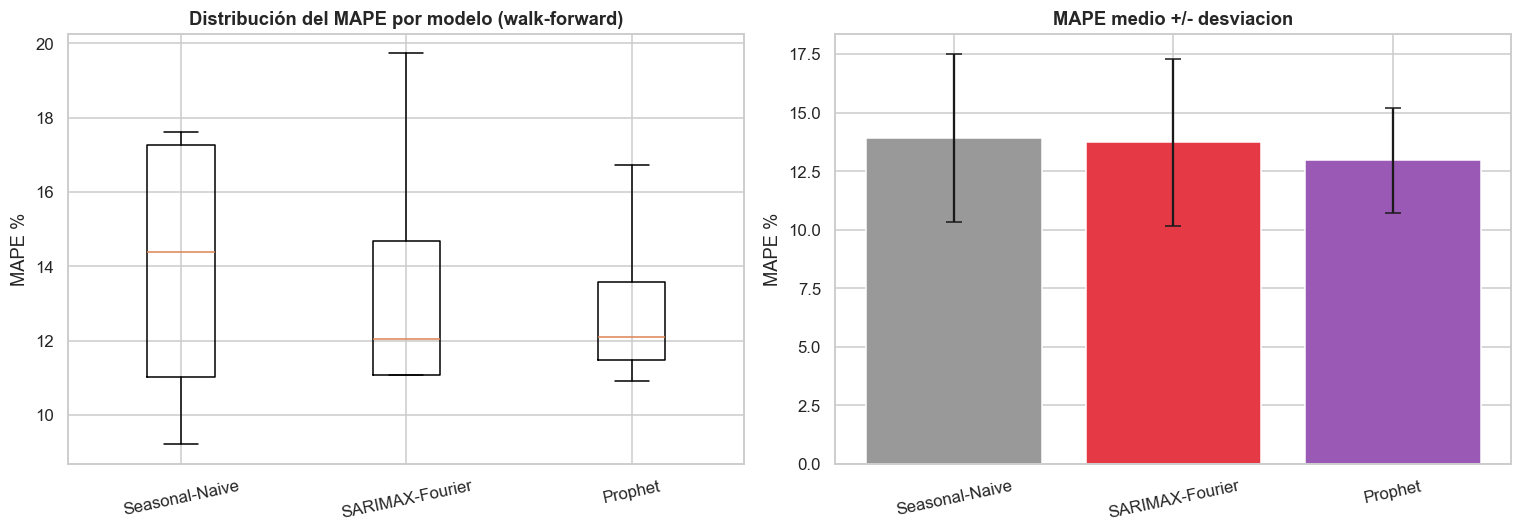

In [3]:
mapes = {m: [f["mape"] for f in folds] for m, folds in per_fold.items()}
fig, ax = plt.subplots(1, 2, figsize=(14,5))
# boxplot de la distribución de MAPE por modelo
ax[0].boxplot(mapes.values(), labels=mapes.keys())
ax[0].set_title("Distribución del MAPE por modelo (walk-forward)"); ax[0].set_ylabel("MAPE %")
ax[0].tick_params(axis="x", rotation=12)
# barras de media con barra de error (desviación)
medias = [resumen[m]["mape_mean"] for m in mapes]
errs = [resumen[m]["mape_std"] for m in mapes]
ax[1].bar(list(mapes.keys()), medias, yerr=errs, capsize=5,
          color=["#999","#E63946","#9b59b6"])
ax[1].set_title("MAPE medio +/- desviacion"); ax[1].set_ylabel("MAPE %"); ax[1].tick_params(axis="x", rotation=12)
fig.tight_layout(); fig.savefig(REPORTS/"11_backtesting.png", bbox_inches="tight"); plt.show()

## Conclusión

El walk-forward confirma de forma robusta (varias ventanas, no una sola) qué modelo conviene. El
**naive semanal** sigue siendo un baseline muy fuerte en horizonte corto; **Prophet** compite de
cerca y aporta intervalos y pronóstico a futuro arbitrario (por eso es el que servimos). La
desviación entre ventanas recuerda que un único split puede engañar — por eso backtesteamos.